In [1]:
# AI Investment Opportunity Analyzer
# Notebook 02: Exploratory Data Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Project paths
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"

FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# Load dataset
data_file = RAW_DATA_PATH / "synthetic_investment_opportunities.csv"
df = pd.read_csv(data_file)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 42)


,opportunity_id,opportunity_name,sector,region,competition_level,investment_size_million,capex_million,opex_million,expected_roi_percent,irr_percent,payback_period_years,revenue_growth_percent,profit_margin_percent,npv_million,market_size_billion,market_growth_percent,demand_score,customer_adoption_score,scalability_score,financial_risk_score,regulatory_risk_score,execution_risk_score,market_risk_score,dependency_risk_score,overall_risk_score,vision_2030_alignment_score,economic_diversification_score,job_creation_score,localization_score,quality_of_life_score,strategic_impact_score,environmental_impact_score,social_impact_score,governance_score,sustainability_score,risk_adjusted_roi,profitability_index,payback_efficiency,market_attractiveness_score,financial_strength_score,investment_score,recommendation
0,INV-00001,Tabuk Technology Opportunity,Technology,Tabuk,Low,163.15,91.34,22.63,14.29,17.19,11.70,6.75,8.15,37.19,9.97,3.06,81.65,69.31,68.94,85.81,32.65,53.71,15.70,56.95,48.96,76.84,68.45,100.00,68.27,92.31,81.17,95.59,53.23,83.81,77.54,0.2860,0.2266,1.1252,58.80,40.56,90.00,Invest
1,INV-00002,Asir Healthcare Opportunity,Healthcare,Asir,Medium,67.46,47.73,11.44,19.08,20.73,5.18,7.90,40.00,49.05,15.38,1.28,23.04,79.19,91.22,29.95,17.16,20.65,49.88,42.50,32.03,82.05,100.00,84.51,96.38,91.63,90.91,91.58,65.18,64.37,73.71,0.5777,0.7165,3.0874,49.96,62.20,93.97,Invest
2,INV-00003,Eastern Province Education Opportunity,Education,Eastern Province,High,213.29,165.94,12.03,8.38,7.92,6.69,8.79,19.71,20.20,11.90,9.34,86.52,60.60,86.64,26.35,23.35,40.05,61.84,67.30,43.78,58.19,96.47,54.80,71.68,22.05,60.64,84.57,18.88,54.31,52.59,0.1871,0.0943,1.0897,70.11,36.20,13.07,Reject
3,INV-00004,Madinah Logistics Opportunity,Logistics,Madinah,Medium,23.72,19.82,3.41,16.41,18.17,3.30,11.64,28.78,26.97,9.28,14.04,65.22,22.05,65.52,52.23,39.64,57.27,58.35,37.99,49.10,85.49,80.36,68.48,56.42,54.87,69.12,19.74,54.31,70.71,48.25,0.3275,1.0910,3.8163,55.75,52.93,66.52,Review
4,INV-00005,Qassim Technology Opportunity,Technology,Qassim,High,131.04,84.34,21.33,9.21,9.21,5.91,12.61,21.53,68.98,31.57,8.13,58.12,70.88,42.25,47.58,47.07,82.98,53.51,35.38,53.30,70.13,57.04,100.00,94.91,50.99,74.61,100.00,54.64,63.07,72.57,0.1696,0.5224,1.3329,52.97,38.86,34.98,Reject


In [2]:
# Basic dataset information

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nRecommendation distribution:")
print(df["recommendation"].value_counts())

Rows: 5000
Columns: 42

Missing values:
0

Duplicate rows:
0

Recommendation distribution:
recommendation
Review    2202
Reject    2023
Invest     775
Name: count, dtype: int64


In [3]:
# Data types and non-null counts

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   opportunity_id                  5000 non-null   str    
 1   opportunity_name                5000 non-null   str    
 2   sector                          5000 non-null   str    
 3   region                          5000 non-null   str    
 4   competition_level               5000 non-null   str    
 5   investment_size_million         5000 non-null   float64
 6   capex_million                   5000 non-null   float64
 7   opex_million                    5000 non-null   float64
 8   expected_roi_percent            5000 non-null   float64
 9   irr_percent                     5000 non-null   float64
 10  payback_period_years            5000 non-null   float64
 11  revenue_growth_percent          5000 non-null   float64
 12  profit_margin_percent           5000 non-null

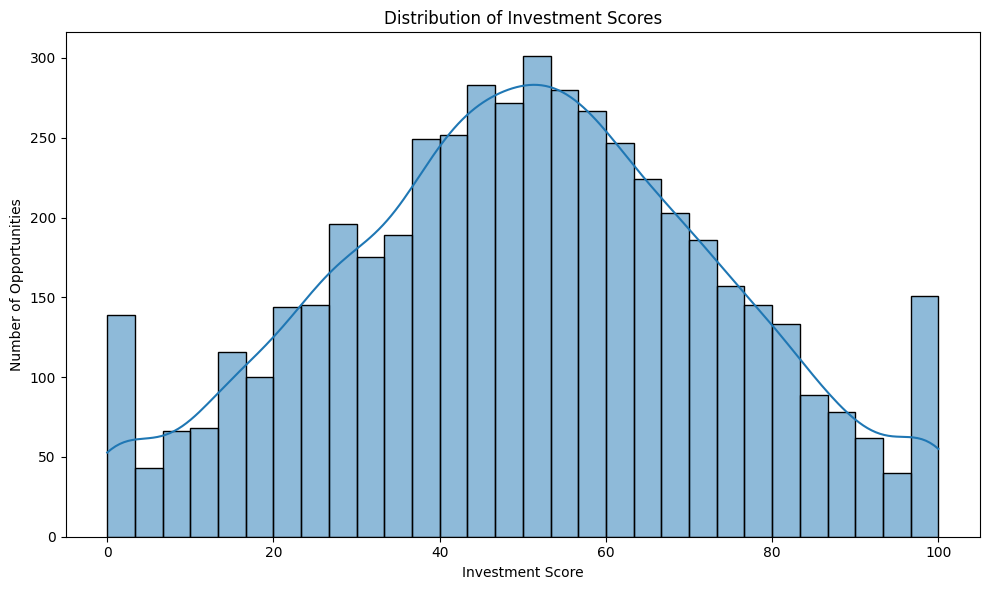

In [4]:
# Investment score distribution

plt.figure(figsize=(10, 6))
sns.histplot(df["investment_score"], bins=30, kde=True)
plt.title("Distribution of Investment Scores")
plt.xlabel("Investment Score")
plt.ylabel("Number of Opportunities")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "investment_score_distribution.png", dpi=300)
plt.show()

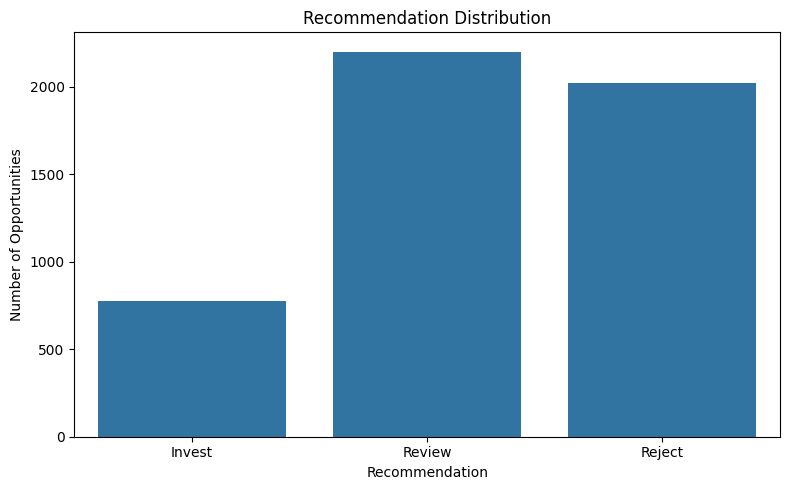

In [5]:
# Recommendation distribution

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="recommendation",
    order=["Invest", "Review", "Reject"]
)
plt.title("Recommendation Distribution")
plt.xlabel("Recommendation")
plt.ylabel("Number of Opportunities")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "recommendation_distribution.png", dpi=300)
plt.show()

In [6]:
# Recommendation percentages

recommendation_summary = (
    df["recommendation"]
    .value_counts()
    .reindex(["Invest", "Review", "Reject"])
    .reset_index()
)

recommendation_summary.columns = ["recommendation", "count"]
recommendation_summary["percentage"] = (
    recommendation_summary["count"] / len(df) * 100
).round(2)

recommendation_summary

,recommendation,count,percentage
0,Invest,775,15.50
1,Review,2202,44.04
2,Reject,2023,40.46


In [7]:
# Average investment score by sector

sector_score = (
    df.groupby("sector")["investment_score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sector_score

,sector,investment_score
0,Renewable Energy,55.200097
1,Technology,52.306667
2,Infrastructure,51.465282
3,Healthcare,51.398374
4,Tourism,51.143426
5,Entertainment,49.701715
6,Education,49.587035
7,Logistics,48.747061
8,Real Estate,48.590544
9,Retail,45.868765


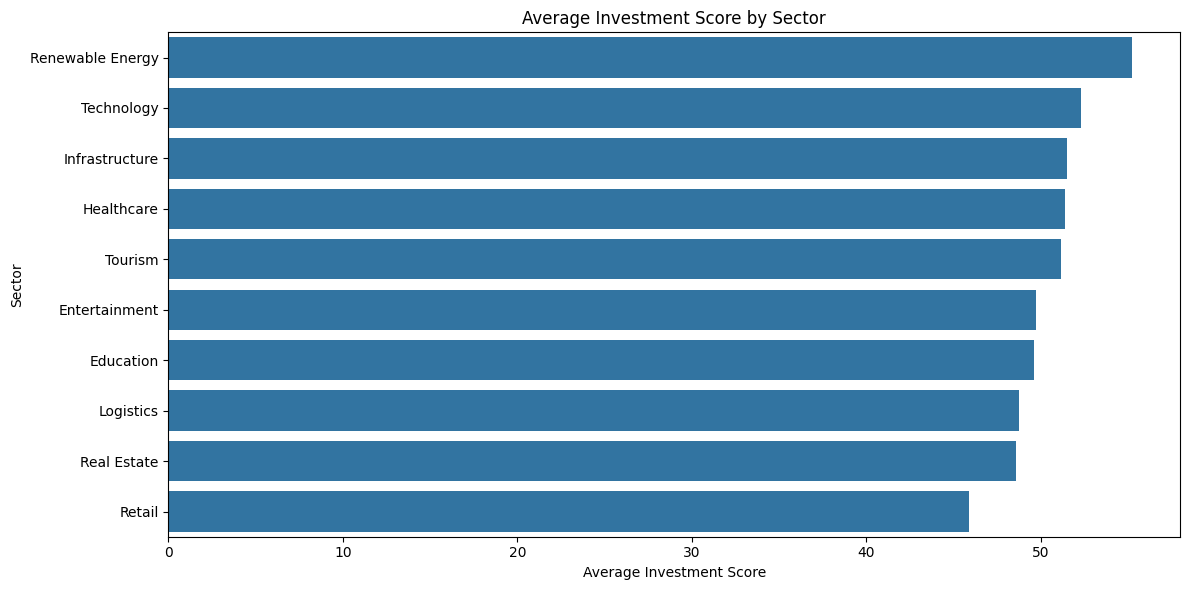

In [8]:
# Plot average investment score by sector

plt.figure(figsize=(12, 6))
sns.barplot(
    data=sector_score,
    x="investment_score",
    y="sector"
)

plt.title("Average Investment Score by Sector")
plt.xlabel("Average Investment Score")
plt.ylabel("Sector")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "average_score_by_sector.png", dpi=300)
plt.show()

In [9]:
# Number of opportunities by sector

sector_counts = (
    df["sector"]
    .value_counts()
    .reset_index()
)

sector_counts.columns = ["sector", "count"]
sector_counts

,sector,count
0,Real Estate,533
1,Education,516
2,Entertainment,513
3,Renewable Energy,513
4,Logistics,507
5,Infrastructure,496
6,Healthcare,486
7,Retail,486
8,Technology,480
9,Tourism,470


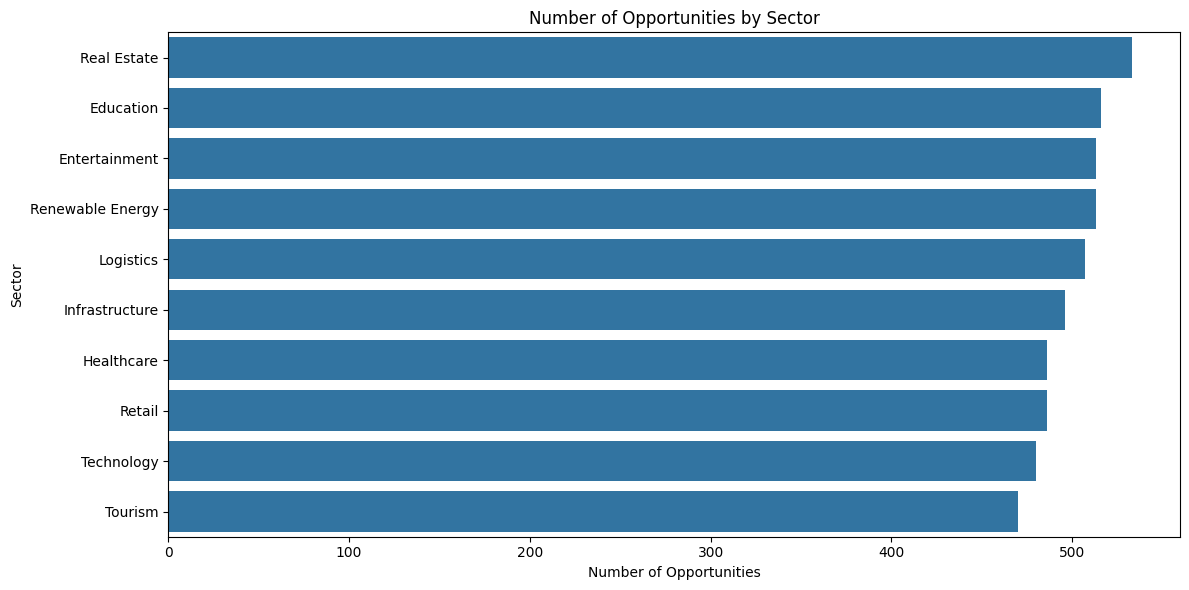

In [10]:
# Plot number of opportunities by sector

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    y="sector",
    order=df["sector"].value_counts().index
)

plt.title("Number of Opportunities by Sector")
plt.xlabel("Number of Opportunities")
plt.ylabel("Sector")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "opportunities_by_sector.png", dpi=300)
plt.show()

In [11]:
# Average investment score by region

region_score = (
    df.groupby("region")["investment_score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

region_score

,region,investment_score
0,Asir,52.471855
1,Makkah,50.880714
2,Riyadh,50.669683
3,Jazan,50.594545
4,Qassim,50.341192
5,Eastern Province,49.761192
6,Madinah,49.437174
7,Tabuk,48.967259


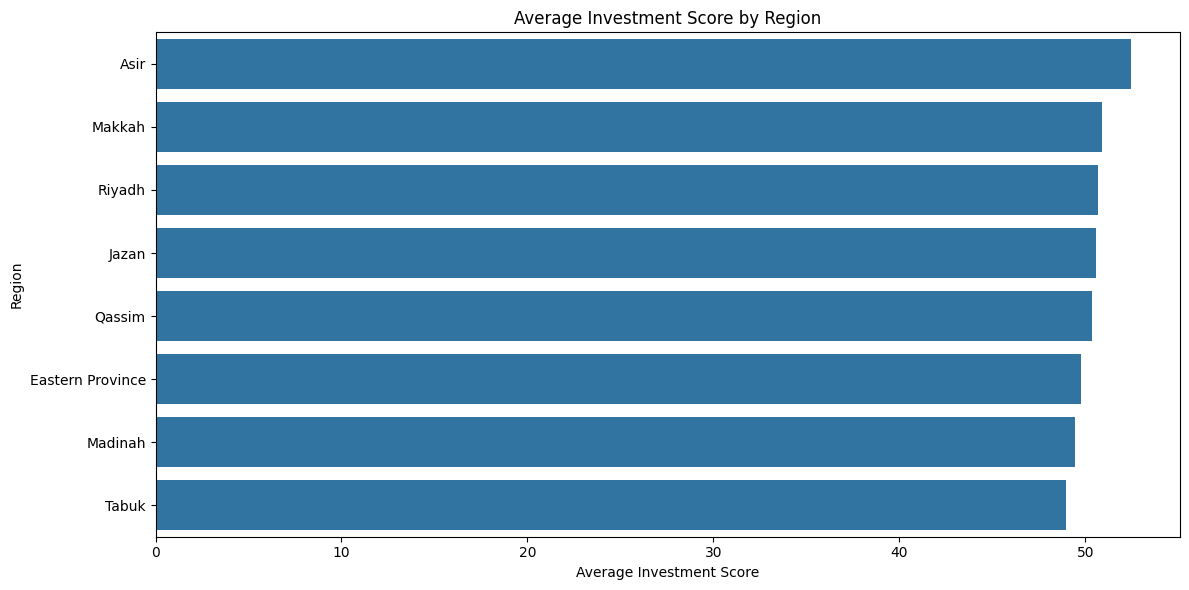

In [12]:
# Plot average investment score by region

plt.figure(figsize=(12, 6))
sns.barplot(
    data=region_score,
    x="investment_score",
    y="region"
)

plt.title("Average Investment Score by Region")
plt.xlabel("Average Investment Score")
plt.ylabel("Region")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "average_score_by_region.png", dpi=300)
plt.show()

In [13]:
# Number of opportunities by region

region_counts = (
    df["region"]
    .value_counts()
    .reset_index()
)

region_counts.columns = ["region", "count"]
region_counts

,region,count
0,Makkah,686
1,Tabuk,642
2,Eastern Province,621
3,Qassim,621
4,Asir,620
5,Madinah,605
6,Jazan,605
7,Riyadh,600


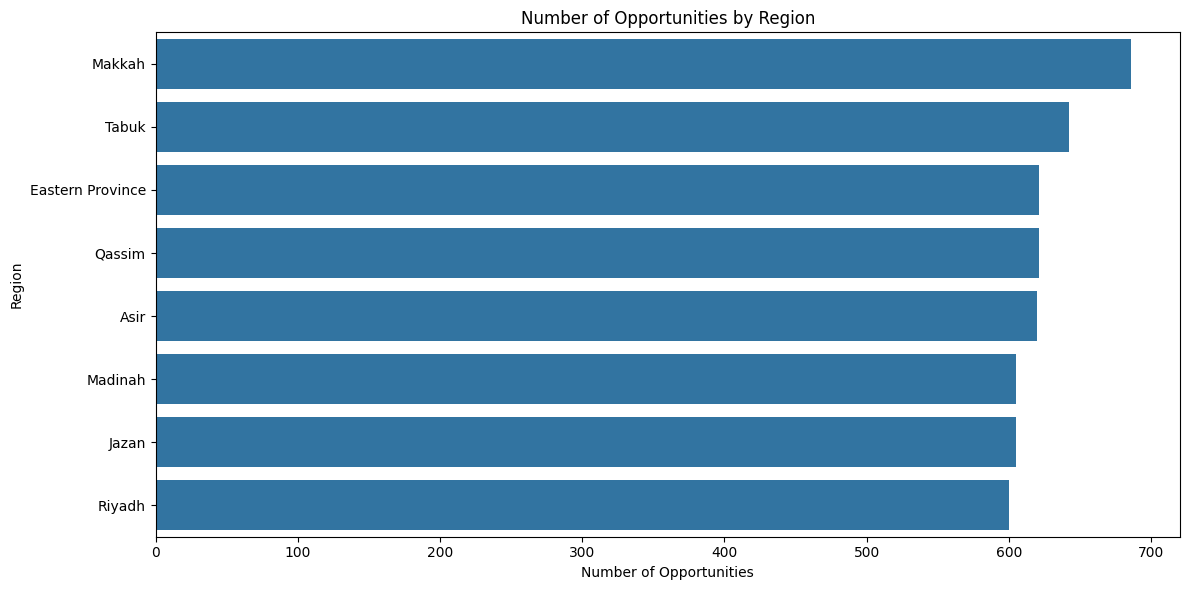

In [14]:
# Plot number of opportunities by region

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df,
    y="region",
    order=df["region"].value_counts().index
)

plt.title("Number of Opportunities by Region")
plt.xlabel("Number of Opportunities")
plt.ylabel("Region")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "opportunities_by_region.png", dpi=300)
plt.show()

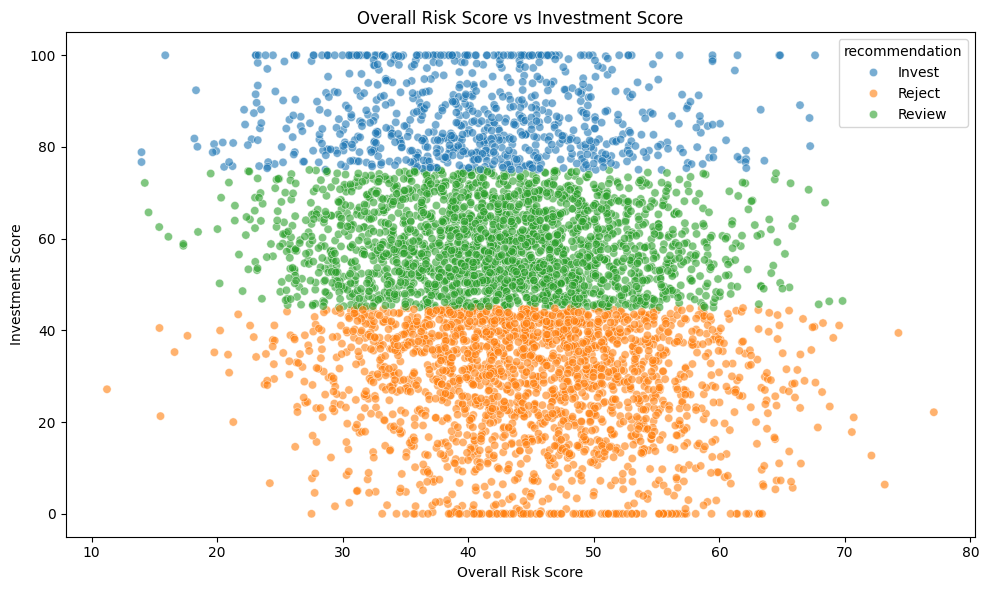

In [15]:
# Risk vs investment score

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="overall_risk_score",
    y="investment_score",
    hue="recommendation",
    alpha=0.6
)

plt.title("Overall Risk Score vs Investment Score")
plt.xlabel("Overall Risk Score")
plt.ylabel("Investment Score")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "risk_vs_investment_score.png", dpi=300)
plt.show()

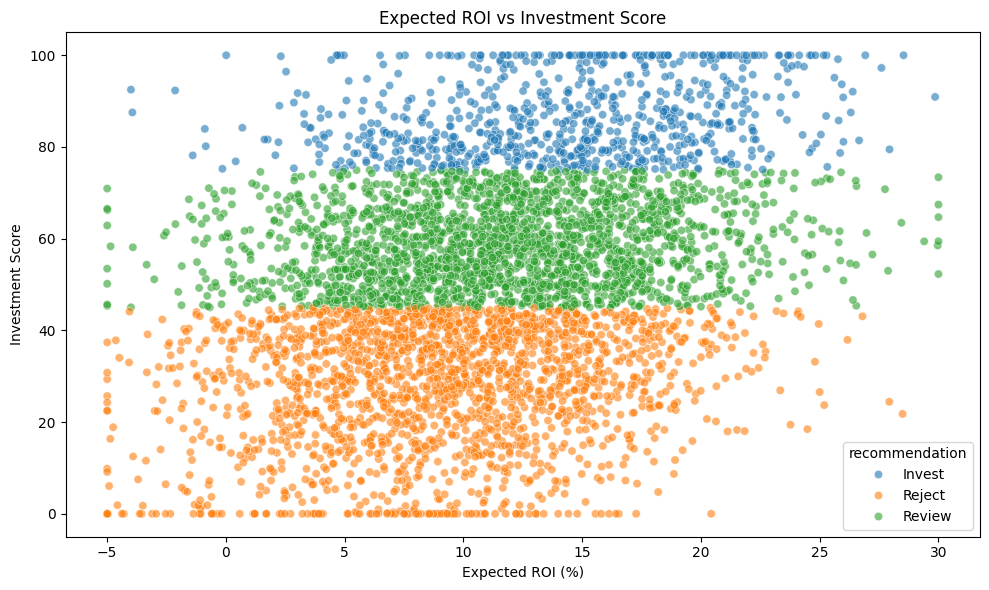

In [16]:
# Expected ROI vs investment score

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="expected_roi_percent",
    y="investment_score",
    hue="recommendation",
    alpha=0.6
)

plt.title("Expected ROI vs Investment Score")
plt.xlabel("Expected ROI (%)")
plt.ylabel("Investment Score")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "roi_vs_investment_score.png", dpi=300)
plt.show()

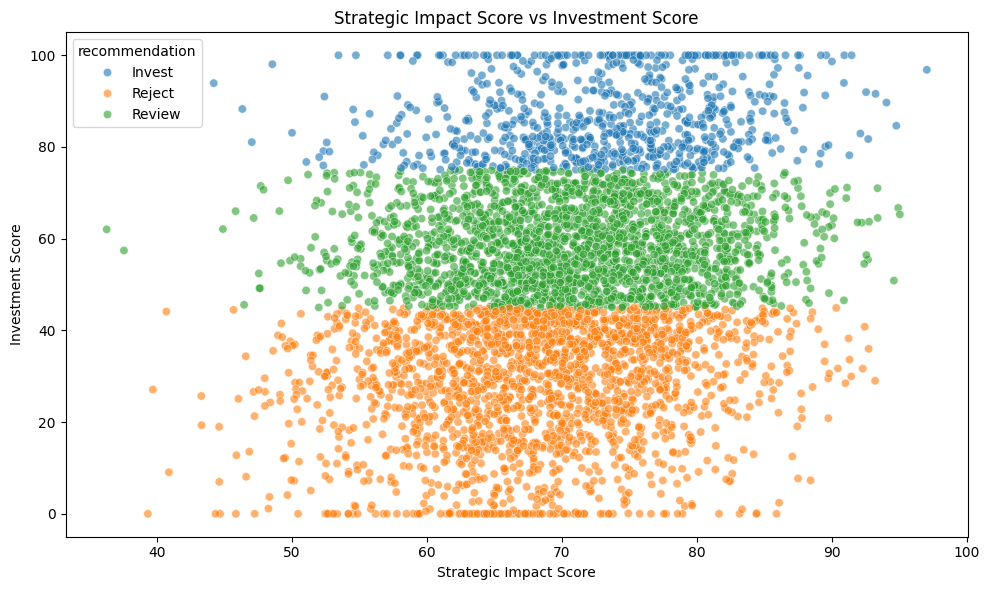

In [17]:
# Strategic impact vs investment score

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="strategic_impact_score",
    y="investment_score",
    hue="recommendation",
    alpha=0.6
)

plt.title("Strategic Impact Score vs Investment Score")
plt.xlabel("Strategic Impact Score")
plt.ylabel("Investment Score")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "strategic_impact_vs_investment_score.png", dpi=300)
plt.show()

In [18]:
# Top 10 investment opportunities by score

top_10_opportunities = (
    df.sort_values(by="investment_score", ascending=False)
    [
        [
            "opportunity_id",
            "opportunity_name",
            "sector",
            "region",
            "investment_score",
            "recommendation",
            "expected_roi_percent",
            "overall_risk_score",
            "strategic_impact_score",
            "sustainability_score"
        ]
    ]
    .head(10)
)

top_10_opportunities

,opportunity_id,opportunity_name,sector,region,investment_score,recommendation,expected_roi_percent,overall_risk_score,strategic_impact_score,sustainability_score
4957,INV-04958,Qassim Technology Opportunity,Technology,Qassim,100.0,Invest,20.46,36.58,91.48,73.81
4989,INV-04990,Asir Infrastructure Opportunity,Infrastructure,Asir,100.0,Invest,14.45,35.89,63.08,82.79
3382,INV-03383,Madinah Healthcare Opportunity,Healthcare,Madinah,100.0,Invest,15.51,53.01,64.24,48.31
1407,INV-01408,Riyadh Retail Opportunity,Retail,Riyadh,100.0,Invest,10.72,44.31,59.35,75.31
3583,INV-03584,Asir Real Estate Opportunity,Real Estate,Asir,100.0,Invest,15.97,44.90,74.80,80.67
3810,INV-03811,Jazan Healthcare Opportunity,Healthcare,Jazan,100.0,Invest,16.75,46.23,79.16,61.77
1520,INV-01521,Makkah Technology Opportunity,Technology,Makkah,100.0,Invest,19.26,34.81,75.35,63.29
1425,INV-01426,Riyadh Logistics Opportunity,Logistics,Riyadh,100.0,Invest,20.10,59.45,86.58,67.56
1437,INV-01438,Asir Retail Opportunity,Retail,Asir,100.0,Invest,13.22,31.15,74.66,58.79
1219,INV-01220,Riyadh Infrastructure Opportunity,Infrastructure,Riyadh,100.0,Invest,20.88,39.11,74.99,62.89


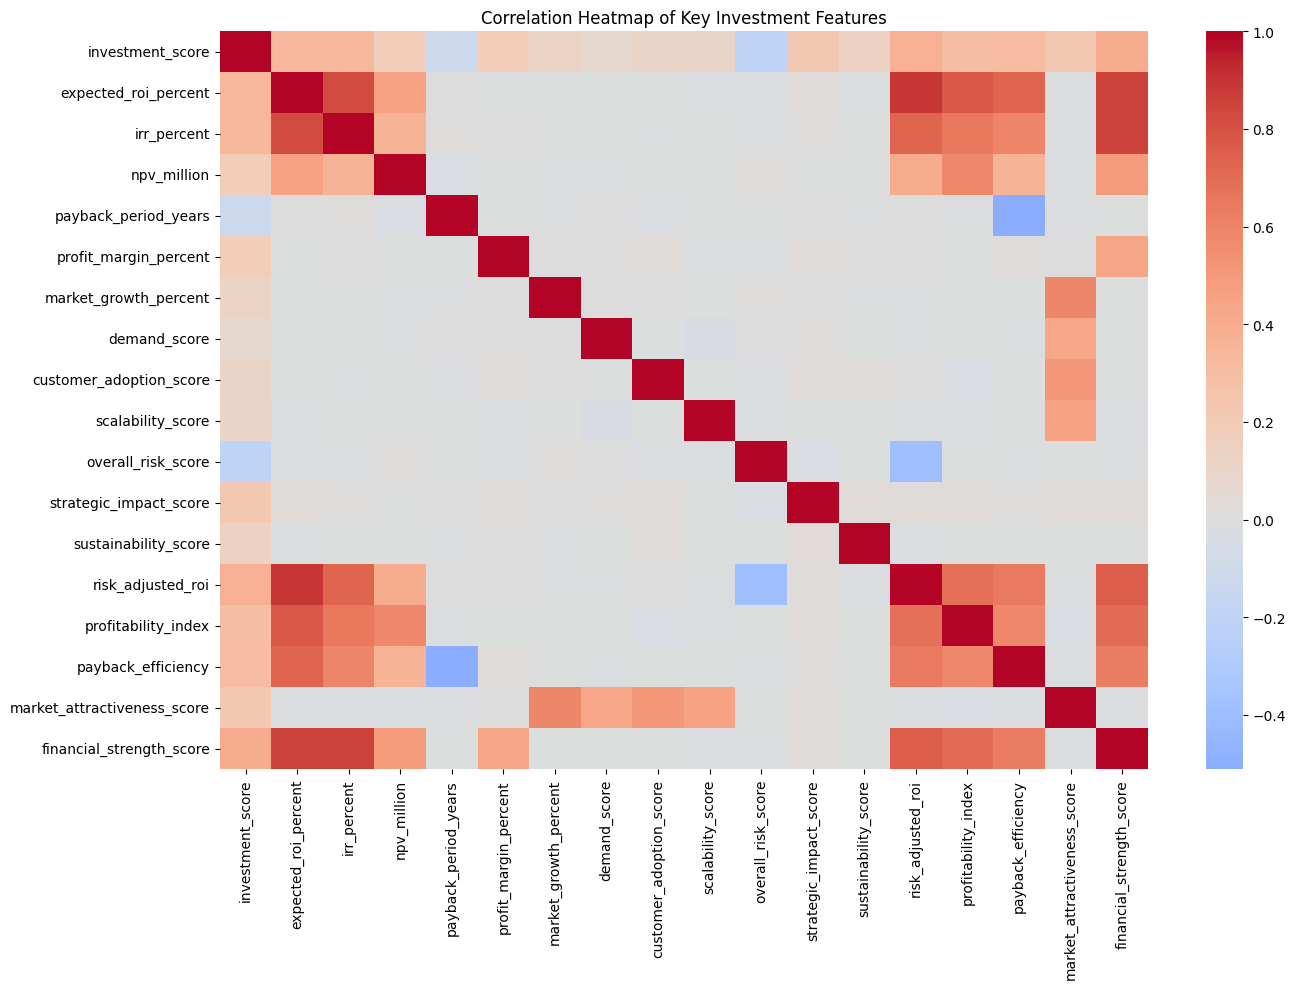

In [19]:
# Correlation heatmap for key numerical features

correlation_features = [
    "investment_score",
    "expected_roi_percent",
    "irr_percent",
    "npv_million",
    "payback_period_years",
    "profit_margin_percent",
    "market_growth_percent",
    "demand_score",
    "customer_adoption_score",
    "scalability_score",
    "overall_risk_score",
    "strategic_impact_score",
    "sustainability_score",
    "risk_adjusted_roi",
    "profitability_index",
    "payback_efficiency",
    "market_attractiveness_score",
    "financial_strength_score"
]

corr_matrix = df[correlation_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Key Investment Features")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "correlation_heatmap.png", dpi=300)
plt.show()

In [20]:
# Correlation with investment score

score_correlations = (
    corr_matrix["investment_score"]
    .sort_values(ascending=False)
    .reset_index()
)

score_correlations.columns = ["feature", "correlation_with_investment_score"]
score_correlations

,feature,correlation_with_investment_score
0,investment_score,1.000000
1,financial_strength_score,0.399506
2,risk_adjusted_roi,0.377389
3,expected_roi_percent,0.340214
4,irr_percent,0.334927
5,payback_efficiency,0.303614
6,profitability_index,0.291636
7,strategic_impact_score,0.225755
8,market_attractiveness_score,0.221417
9,profit_margin_percent,0.184944


In [21]:
# Save top 10 opportunities table

top_10_file = PROJECT_ROOT / "reports" / "top_10_opportunities.csv"
top_10_opportunities.to_csv(top_10_file, index=False)

print(f"Top 10 opportunities saved to: {top_10_file}")

Top 10 opportunities saved to: d:\Senior last\ML\ai-investment-opportunity-analyzer\reports\top_10_opportunities.csv


In [22]:
# Save EDA summary tables

sector_score.to_csv(PROJECT_ROOT / "reports" / "sector_score_summary.csv", index=False)
region_score.to_csv(PROJECT_ROOT / "reports" / "region_score_summary.csv", index=False)
recommendation_summary.to_csv(PROJECT_ROOT / "reports" / "recommendation_summary.csv", index=False)
score_correlations.to_csv(PROJECT_ROOT / "reports" / "score_correlations.csv", index=False)

print("EDA summary files saved successfully.")

EDA summary files saved successfully.
